# Mini Project: Image Enhancement for Selected Poor Quality Images

This notebook covers the four required categories:

1. Component Extraction
2. Enhancement of Blurry Images
3. Noise Removal
4. Visual Enhancement

For each task, the notebook includes:
- Technique used and why it was selected
- Python code
- Output of the technique
- Discussion of results

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [35]:
def load_gray(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {path}")
    return img

def load_color(path):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {path}")
    return img

def show_gray(original, processed, title1="Original", title2="Processed", figsize=(12,5)):
    plt.figure(figsize=figsize)
    plt.subplot(1,2,1)
    plt.imshow(original, cmap='gray')
    plt.title(title1)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(processed, cmap='gray')
    plt.title(title2)
    plt.axis("off")
    plt.show()

def show_color(original, processed, title1="Original", title2="Processed", figsize=(12,5)):
    plt.figure(figsize=figsize)
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title(title1)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(processed, cv2.COLOR_BGR2RGB))
    plt.title(title2)
    plt.axis("off")
    plt.show()

## 1. Component Extraction — Circle

### Technique Used
Hough Circle Transform

### Why this technique was selected
The Hough Circle Transform is effective for detecting circular shapes in images. It identifies circles based on edge information and is robust to noise and partial boundaries.

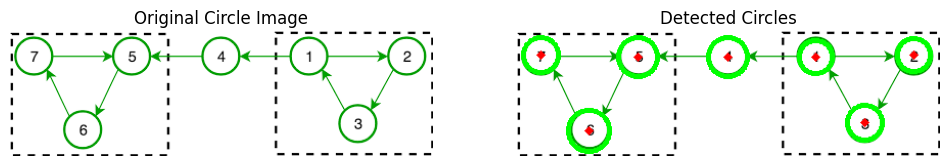

True

In [66]:
img = load_color('/content/7 circles.png')
output = img.copy()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.medianBlur(gray, 5)

circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=40,
    param1=100,
    param2=35,
    minRadius=15,
    maxRadius=35
)

if circles is not None:
    circles = np.round(circles[0, :]).astype(int)
    for (x, y, r) in circles:
        cv2.circle(output, (x, y), r, (0, 255, 0), 3)
        cv2.circle(output, (x, y), 2, (0, 0, 255), 3)

show_color(img, output, "Original Circle Image", "Detected Circles")
cv2.imwrite('/content/output_circle.jpg', output)

### Discussion of Results

**Pros**
- Accurately detects circular shapes.
- Works well even with slight noise.

**Cons**
- Sensitive to parameter tuning.
- May detect false circles if not properly configured.

**Failure Reasons**
- Weak or unclear edges.
- Incorrect parameter values.

**Suggestions for Improvement**
- Apply edge enhancement before detection.
- Fine-tune radius and threshold parameters.

## 2. Component Extraction — COVID-19 Chart

### Technique Used
Thresholding + Contour Detection

### Why this technique was selected
Thresholding separates objects from the background, and contour detection identifies connected components. This combination is effective for extracting visual elements such as icons from structured images.

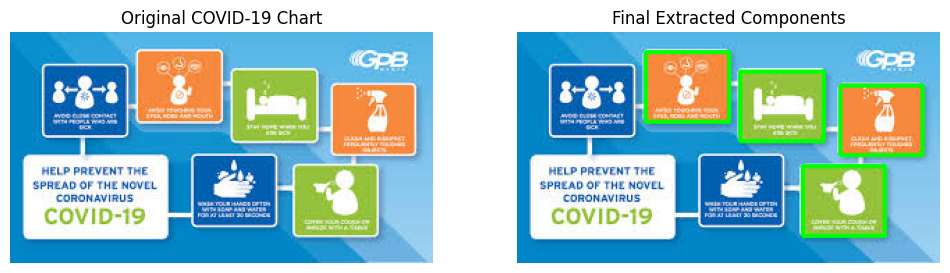

True

In [65]:
img = load_color('/content/Multi_objects_separation.jpeg')
output = img.copy()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

kernel = np.ones((3, 3), np.uint8)
cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

contours, _ = cv2.findContours(cleaned, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    area = cv2.contourArea(cnt)

    if 1500 < area < 30000:
        x, y, w, h = cv2.boundingRect(cnt)

        ratio = w / float(h)

        if 0.6 < ratio < 2.0:
            cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)

show_color(img, output, "Original COVID-19 Chart", "Final Extracted Components")
cv2.imwrite('/content/output_covid_final.jpg', output)

### Discussion of Results

**Pros**
- Successfully detects main visual components.
- Simple and efficient.

**Cons**
- May miss smaller components.
- Some extra bounding boxes may appear.

**Failure Reasons**
- Low contrast between objects and background.
- Complex shapes that do not match filtering criteria.

**Suggestions for Improvement**
- Use color-based segmentation.
- Apply adaptive thresholding for better separation.

## 3. Enhancement of Blurry Images — Building

### Technique Used
Unsharp Masking (Sharpening)

### Why this technique was selected
Sharpening enhances edges and improves visual clarity in blurred images. It is simple to implement and effective for moderate blur.

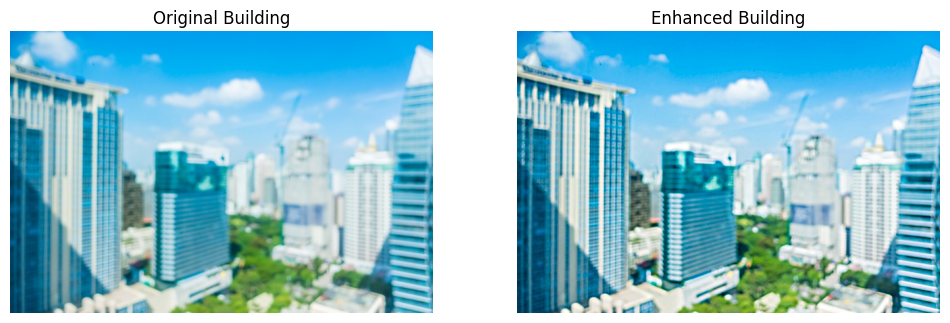

True

In [67]:
img = load_color('/content/Building.jpg')

blur = cv2.GaussianBlur(img, (0, 0), 3)
sharp = cv2.addWeighted(img, 2.0, blur, -1.0, 0)

show_color(img, sharp, "Original Building", "Enhanced Building")
cv2.imwrite('/content/output_building_enhanced.jpg', sharp)

### Discussion of Results

**Pros**
- Improves edge visibility.
- Enhances overall clarity.

**Cons**
- Cannot fully restore heavily blurred regions.
- May introduce slight artifacts.

**Failure Reasons**
- Severe blur in the original image.
- Loss of detail during image capture.

**Suggestions for Improvement**
- Use deconvolution methods such as Wiener filtering.
- Combine with denoising for better results.

## 4. Enhancement of Blurry Images — Dog

### Technique Used
Unsharp Masking

### Why this technique was selected
The image contains noticeable blur, so sharpening helps improve visibility of edges and the main subject.

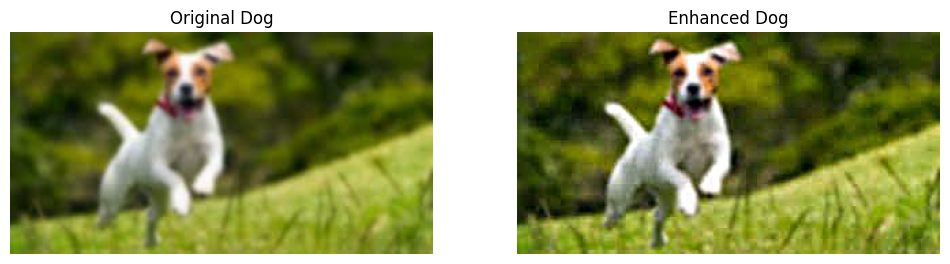

True

In [39]:
img = load_color('/content/Dog.jpeg')

blur = cv2.GaussianBlur(img, (0, 0), 2)
sharp = cv2.addWeighted(img, 2.5, blur, -1.5, 0)

show_color(img, sharp, "Original Dog", "Enhanced Dog")
cv2.imwrite('/content/output_dog_enhanced.jpg', sharp)

### Discussion of Results

**Pros**
- Enhances subject visibility.
- Improves edge sharpness.

**Cons**
- Some blur remains.
- Over-sharpening may distort details.

**Failure Reasons**
- Strong defocus blur.
- Missing high-frequency details.

**Suggestions for Improvement**
- Use advanced deblurring techniques.
- Apply learning-based restoration methods.

## 5. Noise Removal — Text

### Technique Used
Bilateral Filtering + OTSU Thresholding

### Why this technique was selected
Bilateral filtering reduces noise while preserving edges, and OTSU thresholding converts the image into a clean binary form, improving text readability.

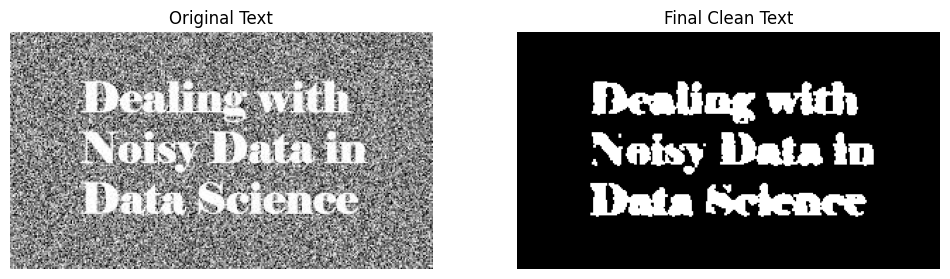

True

In [71]:
img = load_gray('/content/Text.jpeg')

denoised = cv2.bilateralFilter(img, 9, 75, 75)

blur = cv2.GaussianBlur(denoised, (3,3), 0)

_, thresh = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

kernel = np.ones((2,2), np.uint8)
final = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

show_gray(img, final, "Original Text", "Final Clean Text")

cv2.imwrite('/content/output_text_final.jpg', final)

### Discussion of Results

**Pros**
- Significantly reduces noise.
- Improves readability of text.

**Cons**
- Slight distortion of characters.
- Thick edges may appear.

**Failure Reasons**
- High noise level in the original image.
- Loss of fine details.

**Suggestions for Improvement**
- Apply morphological refinement.
- Use OCR-based enhancement methods.

## 6. Noise Removal — Rocket

### Technique Used
Non-Local Means Denoising (fastNlMeansDenoisingColored)

### Why this technique was selected
The rocket image contains noticeable random noise. Non-Local Means denoising was chosen because it effectively reduces noise while preserving edges and important details better than simple filters like Gaussian or median blur.

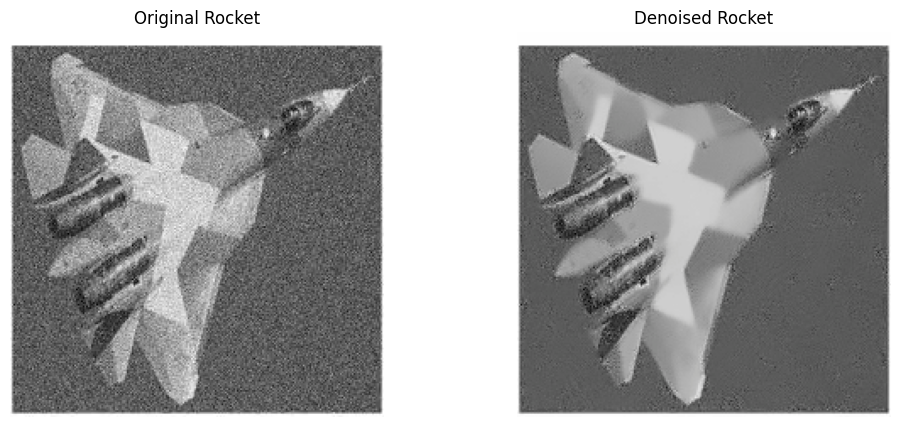

True

In [41]:
img = load_color('/content/Rocket.jpeg')

denoised = cv2.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)

show_color(img, denoised, "Original Rocket", "Denoised Rocket")
cv2.imwrite('/content/output_rocket_denoised.jpg', denoised)

### Discussion of Results

**Pros**
- Reduces noise effectively while preserving image details.
- Maintains edges better than simple smoothing filters.
- Produces a cleaner and more visually appealing image.

**Cons**
- Computationally more expensive than basic filters.
- Over-smoothing may occur if parameters are too high.

**Failure Reasons**
- Extremely high noise levels.
- Incorrect parameter tuning.

**Suggestions for Improvement**
- Fine-tune denoising strength parameters.
- Combine with sharpening for better clarity.
- Explore advanced methods such as BM3D or deep learning-based denoising.

## 6. Noise Removal — Wind Chart

### Technique Used
Median Filtering + Morphological Processing

### Why this technique was selected
The image contains structured vertical noise. Morphological operations help detect and reduce these patterns while preserving the main chart structure.

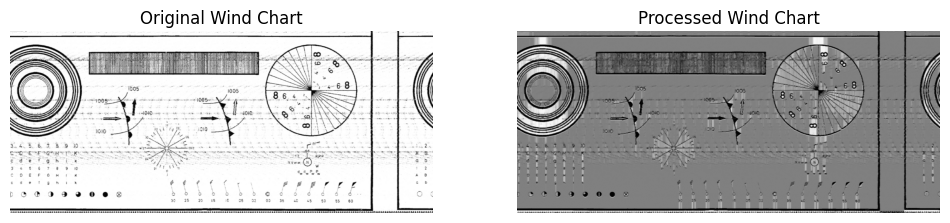

True

In [75]:
img = load_gray('/content/Noisy_1.png')

denoised = cv2.medianBlur(img, 3)

vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 20))
vertical_lines = cv2.morphologyEx(denoised, cv2.MORPH_OPEN, vertical_kernel)

processed = cv2.addWeighted(denoised, 1.0, vertical_lines, -0.5, 0)

show_gray(img, processed, "Original Wind Chart", "Processed Wind Chart")

cv2.imwrite('/content/output_wind_chart_processed.jpg', processed)

### Discussion of Results

**Pros**
- Reduces structured noise.
- Preserves important chart elements.

**Cons**
- Slight loss of contrast.
- Some noise may remain.

**Failure Reasons**
- Strong overlapping noise patterns.
- Thin lines affected during processing.

**Suggestions for Improvement**
- Use directional filters.
- Combine with contrast enhancement.

## 7. Visual Enhancement — Newspaper

### Technique Used
Bilateral Filtering + OTSU Thresholding

### Why this technique was selected
The newspaper image suffers from noise and uneven intensity. Bilateral filtering was used to reduce noise while preserving edges, followed by OTSU thresholding to convert the image into a high-contrast binary form, improving text readability.

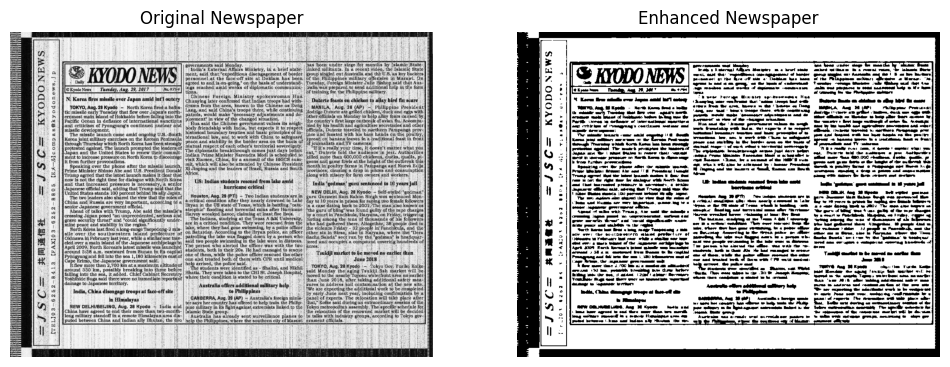

True

In [74]:
img = load_gray('/content/Noisy_2.jpg')

denoised = cv2.bilateralFilter(img, 9, 75, 75)
blur = cv2.GaussianBlur(denoised, (3,3), 0)

_, thresh = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

kernel = np.ones((2,2), np.uint8)
final = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

show_gray(img, final, "Original Newspaper", "Enhanced Newspaper")
cv2.imwrite('/content/output_newspaper_final.jpg', final)

### Discussion of Results

**Pros**
- Significantly improves text readability.
- Removes most of the background noise.
- Enhances contrast between text and background.

**Cons**
- Some fine details are lost due to strong thresholding.
- Edges may appear slightly harsh.

**Failure Reasons**
- Very high noise in the original image.
- Uneven illumination across the image.

**Suggestions for Improvement**
- Use CLAHE before thresholding for better contrast control.
- Apply adaptive thresholding for more localized enhancement.
- Use document-specific enhancement techniques for better preservation of fine details.

## 8. Visual Enhancement — Name Plate

### Technique Used
CLAHE

### Why this technique was selected
CLAHE enhances contrast locally, making text clearer in images with poor lighting.

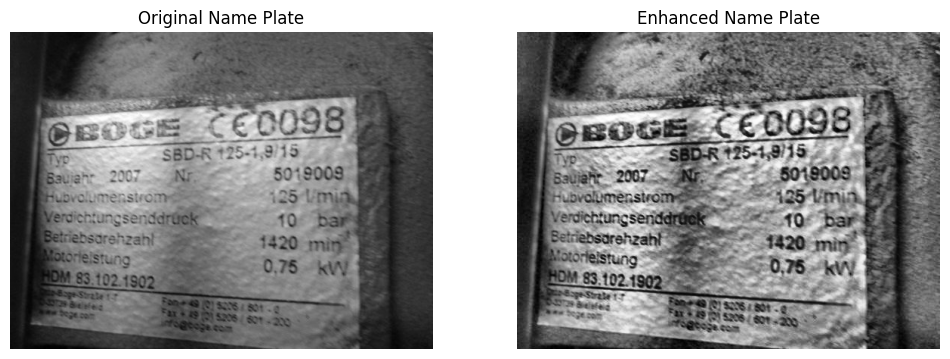

True

In [49]:
img = load_gray('/content/Name plate.jpg')

enhancer = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
enhanced = enhancer.apply(img)

show_gray(img, enhanced, "Original Name Plate", "Enhanced Name Plate")
cv2.imwrite('/content/output_nameplate_enhanced.jpg', enhanced)

### Discussion of Results

**Pros**
- Improves readability.
- Enhances local contrast.

**Cons**
- May amplify noise.
- Limited effect on blur.

**Failure Reasons**
- Reflections or glare.
- Very low resolution.

**Suggestions for Improvement**
- Apply preprocessing to remove glare.
- Combine with thresholding.